# MobileNetV2 Performance Comparison Across Devices

# MobileNetV2 Performance Comparison Across Devices

This notebook analyzes the performance of the MobileNetV2 model across different devices (PC, Raspberry Pi, etc.) using benchmark results.

## 1. Imports and Setup

In [ ]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Short device label utilities (Step 11 adjustments) ---
def get_short_device(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    n = name.lower()
    if 'rpi' in n or 'pi' in n:
        return 'Pi5'
    if 'pc' in n or 'i7' in n:
        return 'i7'
    if 'colab' in n or 't4' in n:
        return 'Colab'
    # Fallback: first token or original
    return name.split('_')[0]

FOOTNOTE_SPEC = "Tags: i7=Desktop Intel i7 (16GB RAM), Pi5=Raspberry Pi 5 (8GB), Colab=Google Colab T4"

print("Short label utilities ready.")

## 2. Data Loading and Preprocessing

In [ ]:
def extract_key_metrics(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract device and other metadata
    device_name = data.get('device_info', {}).get('device_name', 'Unknown')
    
    # Extract inference metrics, handling different structures
    if 'inference_results' in data and data['inference_results']:
        inference_data = data['inference_results'][0] # Assuming one model per file
        config_name = next(iter(inference_data))
        metrics_data = inference_data[config_name]
    else:
        # Fallback for older format
        config_name = next(iter(data.get('results', {})))
        metrics_data = data['results'][config_name]

    metrics = {
        'device': device_name,
        'config': config_name,
        'avg_inference_time_ms': metrics_data.get('average_inference_time_ms', 0),
        'throughput_fps': metrics_data.get('throughput_fps', 0),
        'peak_memory_mb': metrics_data.get('peak_memory_mb', 0)
    }
    
    # Calculate memory efficiency
    if metrics['peak_memory_mb'] > 0:
        metrics['memory_efficiency'] = metrics['throughput_fps'] / metrics['peak_memory_mb']
    else:
        metrics['memory_efficiency'] = 0
    
    # Extract network latency impact if available
    if 'network_latency_impact' in data:
        latency_data = data['network_latency_impact']
        metrics['efficiency_no_network'] = latency_data.get('0ms_latency', {}).get('efficiency_ratio')
        metrics['efficiency_500ms_network'] = latency_data.get('500ms_latency', {}).get('efficiency_ratio')
    else:
        metrics['efficiency_no_network'] = None
        metrics['efficiency_500ms_network'] = None
        
    return metrics

# Define file paths for the benchmark results
result_files = {
    'PC': '../results/pc/mobilenetv2_results_20250622_183614.json',
    'RPi': '../results/rpi/mobilenetv2.json'
}

# Load all MobileNetV2 results
all_results = []
for device, file_path in result_files.items():
    try:
        metrics = extract_key_metrics(file_path)
        metrics['device'] = device # Ensure device name is consistent
        all_results.append(metrics)
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

df = pd.DataFrame(all_results)

print("DataFrame Head:")
print(df.head())

## 3. Performance Metrics Visualization

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

plot_df = df.copy()
plot_df['short'] = plot_df['device'].apply(get_short_device)

# Inference Time (ms)
axes[0].bar(plot_df['short'], plot_df['avg_inference_time_ms'], color='#4E79A7')
axes[0].set_title('Inference Time')
axes[0].set_ylabel('ms')
for x, v in enumerate(plot_df['avg_inference_time_ms']):
    axes[0].text(x, v + max(plot_df['avg_inference_time_ms'])*0.01, f"{v:.1f}", ha='center', fontsize=9)

# Peak Memory (MB)
axes[1].bar(plot_df['short'], plot_df['peak_memory_mb'], color='#59A14F')
axes[1].set_title('Peak Memory')
axes[1].set_ylabel('MB')
for x, v in enumerate(plot_df['peak_memory_mb']):
    axes[1].text(x, v + max(plot_df['peak_memory_mb'])*0.01, f"{v:.0f}", ha='center', fontsize=9)

# Throughput (img/s)
axes[2].bar(plot_df['short'], plot_df['throughput_fps'], color='#E15759')
axes[2].set_title('Throughput')
axes[2].set_ylabel('img/s')
for x, v in enumerate(plot_df['throughput_fps']):
    axes[2].text(x, v + max(plot_df['throughput_fps'])*0.01, f"{v:.1f}", ha='center', fontsize=9)

plt.suptitle('MobileNetV2 Device Metrics', fontsize=14, fontweight='bold')
plt.figtext(0.01, -0.02, FOOTNOTE_SPEC, ha='left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Network Latency Impact Analysis

In [ ]:
network_df = df[['device', 'efficiency_no_network', 'efficiency_500ms_network']].copy()
network_df.dropna(inplace=True)

if not network_df.empty:
    network_df.plot(kind='bar', x='device', figsize=(10, 6))
    plt.title('Network Efficiency Comparison (0ms vs 500ms latency)')
    plt.ylabel('Efficiency Ratio (Throughput / Latency)')
    plt.xlabel('Device')
    plt.xticks(rotation=0)
    plt.legend(['0ms Latency', '500ms Latency'])
    plt.show()
else:
    print("No network latency data available to plot.")

## 5. Memory Efficiency Analysis

In [ ]:
tmp = df.copy()
tmp['short'] = tmp['device'].apply(get_short_device)
plt.figure(figsize=(6,4))
plt.bar(tmp['short'], tmp['memory_efficiency'], color='#9C755F')
plt.ylabel('FPS/MB')
plt.title('Memory Efficiency')
for x, v in enumerate(tmp['memory_efficiency']):
    plt.text(x, v + (max(tmp['memory_efficiency'])*0.02 if max(tmp['memory_efficiency'])>0 else 0.01), f"{v:.3f}", ha='center', fontsize=9)
plt.figtext(0.01, -0.05, FOOTNOTE_SPEC, ha='left', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Performance Summary

In [ ]:
summary_df = df.set_index('device')[['avg_inference_time_ms', 'peak_memory_mb', 'throughput_fps', 'memory_efficiency']]
print("Performance Summary:")
print(summary_df)

best_latency = summary_df['avg_inference_time_ms'].idxmin()
best_memory = summary_df['peak_memory_mb'].idxmin()
best_throughput = summary_df['throughput_fps'].idxmax()
best_mem_efficiency = summary_df['memory_efficiency'].idxmax()

print(f"
Best device for low latency: {best_latency}")
print(f"Best device for low memory usage: {best_memory}")
print(f"Best device for high throughput: {best_throughput}")
print(f"Best device for memory efficiency: {best_mem_efficiency}")

# MobileNetV2 Edge AI Device Comparison

This notebook focuses on a detailed comparison of MobileNetV2 performance across all available devices and hardware tiers. It provides in-depth analysis, visualizations, and deployment recommendations specific to MobileNetV2.

In [43]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis timestamp: 2025-06-29 14:47:35


In [44]:
# Define MobileNetV2 result file paths for all devices
result_files = {
    'PC_MobileNetV2': '../results/pc/mobilenetv2_results_20250622_183614.json',
    'RPi_MobileNetV2': '../results/rpi/mobilenetv2.json',
    # Add Colab or other device results if available
    # 'Colab_MobileNetV2': '../results/colab/mobilenetv2.json',
}

def load_benchmark_results(file_path):
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Warning: Could not load {file_path}: {e}")
        return None

def extract_key_metrics(data, device_name):
    if data is None:
        return None
    metrics = {
        'device': device_name,
        'model_name': data['model_info']['name'],
        'model_size_mb': data['model_info']['size_mb'],
        'quantized': data['model_info'].get('quantized', False),
        'framework': 'TensorFlow' if 'tensorflow_version' in data['device_info'] else 'PyTorch',
        'cpu_cores': data['device_info']['cpu_cores'],
        'ram_gb': data['device_info']['total_ram_gb'],
        'system': data['device_info']['system']
    }
    perf = data['core_performance']
    if 'inference_times' in perf:
        inference_times = perf['inference_times']
        metrics.update({
            'avg_inference_time_ms': np.mean(inference_times),
            'min_inference_time_ms': min(inference_times),
            'max_inference_time_ms': max(inference_times),
            'std_inference_time_ms': np.std(inference_times)
        })
    else:
        metrics.update({
            'avg_inference_time_ms': 0,
            'min_inference_time_ms': 0,
            'max_inference_time_ms': 0,
            'std_inference_time_ms': 0
        })
    if 'batch_processing' in data:
        batch_data = data['batch_processing']
        throughputs = []
        memory_usages = []
        for batch_size, batch_info in batch_data.items():
            if str(batch_size).isdigit():
                throughputs.append(batch_info.get('throughput', 0))
                memory_usages.append(batch_info.get('memory_usage', 0))
        metrics['throughput_fps'] = max(throughputs) if throughputs else 0
        metrics['peak_memory_mb'] = max(memory_usages) if memory_usages else 0
        metrics['avg_memory_mb'] = np.mean(memory_usages) if memory_usages else 0
    else:
        metrics['throughput_fps'] = 0
        metrics['peak_memory_mb'] = 0
        metrics['avg_memory_mb'] = 0
    if 'cold_warm_analysis' in data and 'statistics' in data['cold_warm_analysis']:
        metrics['cold_start_time_ms'] = data['cold_warm_analysis']['statistics'].get('startup_overhead', 0)
    else:
        metrics['cold_start_time_ms'] = 0
    if metrics['model_size_mb'] > 0:
        metrics['inference_per_mb'] = metrics['throughput_fps'] / metrics['model_size_mb']
    else:
        metrics['inference_per_mb'] = 0
    if metrics['peak_memory_mb'] > 0:
        metrics['memory_efficiency'] = metrics['throughput_fps'] / metrics['peak_memory_mb']
    else:
        metrics['memory_efficiency'] = 0
    return metrics

# Load all MobileNetV2 results
all_results = []
for config_name, file_path in result_files.items():
    data = load_benchmark_results(file_path)
    if data:
        metrics = extract_key_metrics(data, config_name)
        if metrics:
            if 'timestamp' in data:
                metrics['timestamp'] = data['timestamp']
                metrics['run_id'] = config_name
            all_results.append(metrics)
            print(f"✓ Loaded {config_name}: {metrics['model_name']} on {config_name}")
    else:
        print(f"✗ Failed to load {config_name}")

# Create DataFrame for analysis
if all_results:
    df = pd.DataFrame(all_results)
    print(f"\nDataset created with {len(df)} MobileNetV2 configurations")
    print(df[['device', 'framework', 'avg_inference_time_ms', 'throughput_fps']].to_string(index=False))
else:
    print("No valid MobileNetV2 results loaded. Please check file paths.")

✓ Loaded PC_MobileNetV2: MobileNetV2 on PC_MobileNetV2
✓ Loaded RPi_MobileNetV2: MobileNetV2 on RPi_MobileNetV2

Dataset created with 2 MobileNetV2 configurations
         device  framework  avg_inference_time_ms  throughput_fps
 PC_MobileNetV2 TensorFlow              16.068696       65.609160
RPi_MobileNetV2 TensorFlow              11.868653       84.483041


## MobileNetV2 Performance Visualization

Visualize and compare MobileNetV2 inference time, memory usage, and throughput across devices.

## Network Latency Impact on MobileNetV2 Efficiency

Visualize the effect of network latency (e.g., 0ms vs 500ms) on MobileNetV2 efficiency for each device.

In [ ]:
# Plot network latency impact for PC and RPi only (if data is available)
if not df.empty:
    available_devices = []
    for i, row in df.iterrows():
        device_name = str(row['device']).lower()
        if 'pc' in device_name or 'rpi' in device_name:
            eff0 = row.get('efficiency_no_network', None)
            eff500 = row.get('efficiency_500ms_network', None)
            if pd.notna(eff0) or pd.notna(eff500):
                available_devices.append((i, row['device'], eff0, eff500))
    if available_devices:
        fig, ax = plt.subplots(figsize=(5,4))
        labels = []
        no_net = []
        net500 = []
        for idx, (i, device, eff0, eff500) in enumerate(available_devices):
            short = get_short_device(device)
            labels.append(short)
            no_net.append(eff0 if pd.notna(eff0) else np.nan)
            net500.append(eff500 if pd.notna(eff500) else np.nan)
        x = np.arange(len(labels))
        w = 0.35
        ax.bar(x - w/2, no_net, width=w, label='0ms', color='#4CAF50')
        ax.bar(x + w/2, net500, width=w, label='500ms', color='#FF7043')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel('Eff. (%)')
        ax.set_title('Network Efficiency')
        for xi, v in zip(x - w/2, no_net):
            if not np.isnan(v):
                ax.text(xi, v + 1, f"{v:.1f}", ha='center', fontsize=8)
        for xi, v in zip(x + w/2, net500):
            if not np.isnan(v):
                ax.text(xi, v + 1, f"{v:.1f}", ha='center', fontsize=8)
        ax.set_ylim(0, max([v for v in no_net+net500 if not np.isnan(v)])*1.15)
        ax.legend(frameon=False, ncol=2, loc='upper right', title='Latency')
        plt.figtext(0.01, -0.08, FOOTNOTE_SPEC, ha='left', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print("No network efficiency data available for PC or RPi.")
else:
    print("No data to visualize.")

No network efficiency data available for PC or RPi.


## MobileNetV2 Deployment Recommendations

Based on the analysis, recommend the best device for deploying MobileNetV2 in edge AI scenarios.

In [46]:
# Deployment recommendation for MobileNetV2
if not df.empty:
    best_latency = df.loc[df['avg_inference_time_ms'].idxmin()]
    best_throughput = df.loc[df['throughput_fps'].idxmax()]
    best_memory = df.loc[df['avg_memory_mb'].idxmin()]
    print("=== MobileNetV2 Deployment Recommendations ===")
    print(f"\n🏆 Fastest Inference: {best_latency['device']} ({best_latency['avg_inference_time_ms']:.2f} ms)")
    print(f"🚀 Highest Throughput: {best_throughput['device']} ({best_throughput['throughput_fps']:.1f} images/sec)")
    print(f"💾 Lowest Memory Usage: {best_memory['device']} ({best_memory['avg_memory_mb']:.1f} MB)")
else:
    print("No data for recommendations.")

=== MobileNetV2 Deployment Recommendations ===

🏆 Fastest Inference: RPi_MobileNetV2 (11.87 ms)
🚀 Highest Throughput: RPi_MobileNetV2 (84.5 images/sec)
💾 Lowest Memory Usage: PC_MobileNetV2 (384.9 MB)


## Summary

This notebook provides a focused analysis of MobileNetV2 performance across all available devices, supporting informed deployment decisions for edge AI applications.

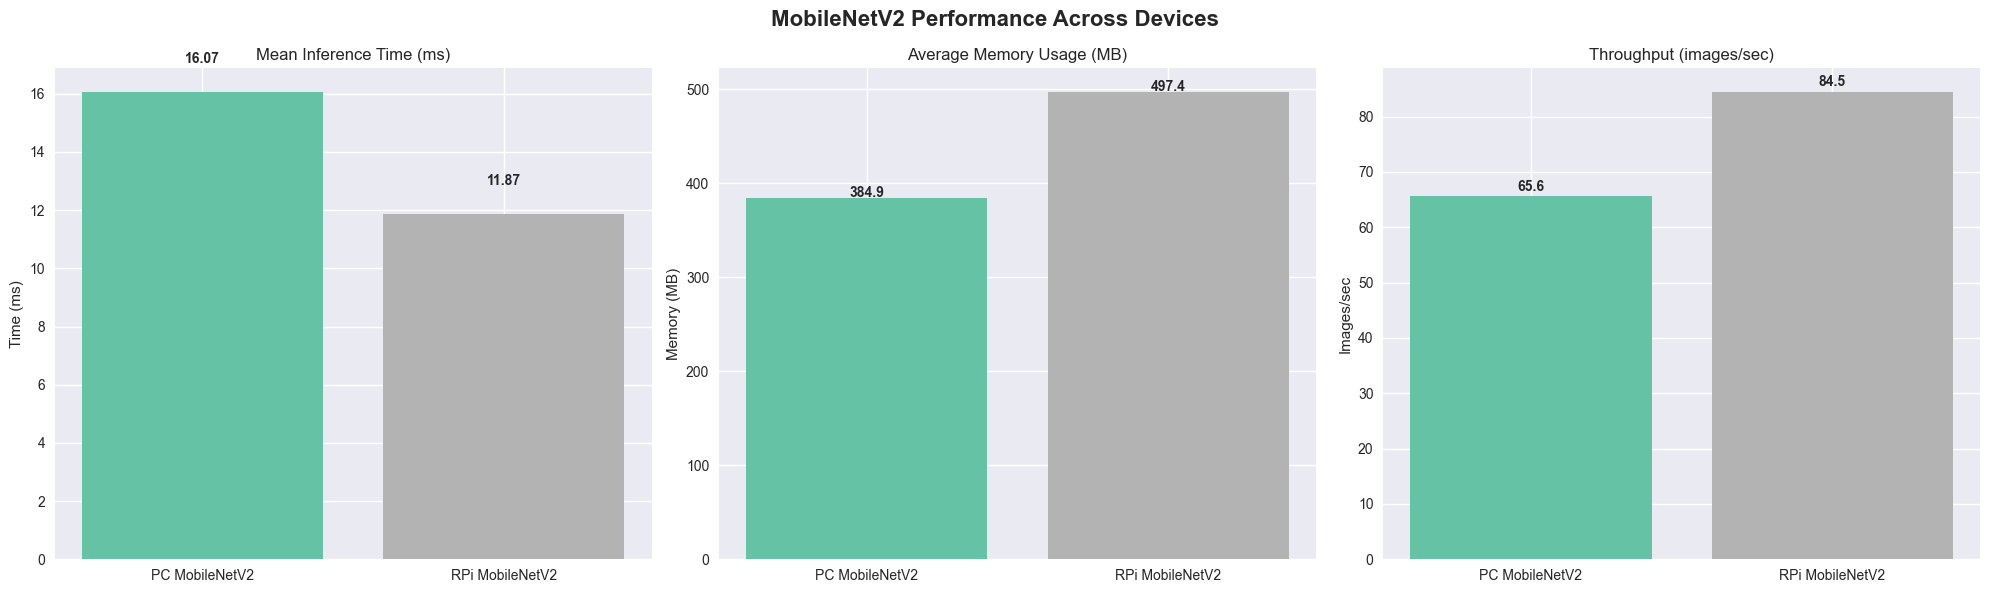

In [ ]:
# MobileNetV2: Inference Time, Memory Usage, Throughput Plots
if not df.empty:
    plot_df = df.copy()
    plot_df['short'] = plot_df['device'].apply(get_short_device)
    fig, axes = plt.subplots(1, 3, figsize=(14,4.5))
    fig.suptitle('MobileNetV2 Performance', fontsize=14, fontweight='bold')
    colors = plt.cm.Set2(np.linspace(0,1,len(plot_df)))
    # Inference
    axes[0].bar(plot_df['short'], plot_df['avg_inference_time_ms'], color=colors)
    axes[0].set_title('Inference Time')
    axes[0].set_ylabel('ms')
    for i,v in enumerate(plot_df['avg_inference_time_ms']):
        axes[0].text(i, v + max(plot_df['avg_inference_time_ms'])*0.01, f'{v:.1f}', ha='center', fontsize=8)
    # Memory
    axes[1].bar(plot_df['short'], plot_df['avg_memory_mb'], color=colors)
    axes[1].set_title('Avg Memory')
    axes[1].set_ylabel('MB')
    for i,v in enumerate(plot_df['avg_memory_mb']):
        axes[1].text(i, v + max(plot_df['avg_memory_mb'])*0.01, f'{v:.0f}', ha='center', fontsize=8)
    # Throughput
    axes[2].bar(plot_df['short'], plot_df['throughput_fps'], color=colors)
    axes[2].set_title('Throughput')
    axes[2].set_ylabel('img/s')
    for i,v in enumerate(plot_df['throughput_fps']):
        axes[2].text(i, v + max(plot_df['throughput_fps'])*0.01, f'{v:.1f}', ha='center', fontsize=8)
    plt.figtext(0.01, -0.02, FOOTNOTE_SPEC, ha='left', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

In [ ]:
# MobileNetV2: Network Latency Impact Plots (per device, as available)
if not df.empty:
    available_devices = []
    for i, row in df.iterrows():
        eff0 = row.get('efficiency_no_network', None)
        eff500 = row.get('efficiency_500ms_network', None)
        if pd.notna(eff0) or pd.notna(eff500):
            available_devices.append((i, row['device'], eff0, eff500))
    if available_devices:
        fig, ax = plt.subplots(figsize=(5,4))
        labels = []
        no_net = []
        net500 = []
        for (i, device, eff0, eff500) in available_devices:
            short = get_short_device(device)
            labels.append(short)
            no_net.append(eff0 if pd.notna(eff0) else np.nan)
            net500.append(eff500 if pd.notna(eff500) else np.nan)
        x = np.arange(len(labels))
        w = 0.35
        ax.bar(x - w/2, no_net, width=w, label='0ms', color='#4CAF50')
        ax.bar(x + w/2, net500, width=w, label='500ms', color='#FF7043')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel('Eff. (%)')
        ax.set_title('Network Efficiency')
        ymax = 0
        for xi, v in zip(x - w/2, no_net):
            if not np.isnan(v):
                ax.text(xi, v + 1, f"{v:.1f}", ha='center', fontsize=8)
                ymax = max(ymax, v)
        for xi, v in zip(x + w/2, net500):
            if not np.isnan(v):
                ax.text(xi, v + 1, f"{v:.1f}", ha='center', fontsize=8)
                ymax = max(ymax, v)
        if ymax > 0:
            ax.set_ylim(0, ymax * 1.15)
        ax.legend(frameon=False, ncol=2, loc='upper right', title='Latency')
        plt.figtext(0.01, -0.08, FOOTNOTE_SPEC, ha='left', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print("No network efficiency data available for any device.")
else:
    print("No data to visualize.")

No network efficiency data available for any device.


## 6. Performance Summary

In [ ]:
summary_df = df.set_index('device')[['avg_inference_time_ms', 'peak_memory_mb', 'throughput_fps', 'memory_efficiency']]
print("Performance Summary:")
print(summary_df)

best_latency = summary_df['avg_inference_time_ms'].idxmin()
best_memory = summary_df['peak_memory_mb'].idxmin()
best_throughput = summary_df['throughput_fps'].idxmax()
best_mem_efficiency = summary_df['memory_efficiency'].idxmax()

print(f"
Best device for low latency: {best_latency}")
print(f"Best device for low memory usage: {best_memory}")
print(f"Best device for high throughput: {best_throughput}")
print(f"Best device for memory efficiency: {best_mem_efficiency}")

## Step 6 – Compact Results Figures
The following figures implement the specified condensed styling with short device tags and unified legend.